<a href="https://colab.research.google.com/github/lanaozeki08-jpg/SERS_CP_dataset/blob/main/SERS_CP_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset 1 — Appliances Energy Prediction  (UCI)**

Fonte: https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

**Situação**

Uma empresa de eficiência energética está analisando o comportamento de uma residência de baixo consumo. A equipe deseja identificar períodos de consumo elevado dos eletrodomésticos e observar quais condições de temperatura e umidade estavam presentes nesses momentos.

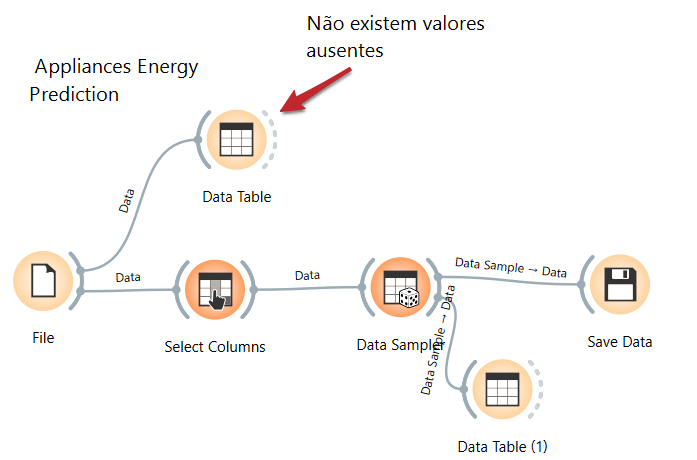

In [ ]:
import pandas as pd

In [ ]:
#criação de um pandas data frame (tabela)
dados = pd.read_csv('/content/energydata_SAMPLE.csv')

In [ ]:
dados.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


In [ ]:
dados.shape

(1974, 8)

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Appliances  1974 non-null   int64  
 1   lights      1974 non-null   int64  
 2   T1          1974 non-null   float64
 3   RH_1        1974 non-null   float64
 4   T2          1974 non-null   float64
 5   RH_2        1974 non-null   float64
 6   T3          1974 non-null   float64
 7   RH_3        1974 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 123.5 KB


In [ ]:
dados.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,93.044580,3.839919,21.664703,40.219193,20.293635,40.411386,22.231615,39.209733
std,93.826149,7.937076,1.574883,3.971923,2.126958,4.037686,1.957275,3.288818
min,20.000000,0.000000,16.790000,27.733300,16.100000,24.063300,17.200000,30.133300
25%,50.000000,0.000000,20.700000,37.205825,18.790000,37.760000,20.700000,36.900000
50%,60.000000,0.000000,21.600000,39.590000,20.000000,40.433300,22.100000,38.433300
75%,100.000000,0.000000,22.600000,42.991675,21.500000,43.228325,23.290000,41.741250
max,770.000000,50.000000,26.260000,57.496700,28.917500,56.026700,29.198600,49.226700


In [ ]:
dados.rename({'Appliances': 'Consumos_Eletrodomesticos',
              'lights': 'luz',
              'T1': 'temperatura_1',
              'T2': 'temperatura_2',
              'T3': 'temperatura_3'}, axis=1, inplace=True)
dados.head()

,Consumos_Eletrodomesticos,luz,temperatura_1,RH_1,temperatura_2,RH_2,temperatura_3,RH_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


In [ ]:
# qual é o maior consumo de eletrodomesticos da amostra?
PMAX = dados['Consumos_Eletrodomesticos'].max()
print(f'O maior valor de consumo é {PMAX:.2f} kWh')

O maior valor de consumo é 770.00 kWh


In [ ]:
#qual é o valor do limiar de 70% do consumo máximo (P70)?
P70 = 0.7 * PMAX
print(f'O valo do limiar de 70% do consumo máximo é: {P70:.2f} kWh')

O valo do limiar de 70% do consumo máximo é: 539.00 kWh


In [ ]:
#dataframe com registros acima do valor limite
df1 = dados[dados['Consumos_Eletrodomesticos'] > P70]
df1.head()

,Consumos_Eletrodomesticos,luz,temperatura_1,RH_1,temperatura_2,RH_2,temperatura_3,RH_3
352,620,0,24.3900,44.3333,25.3700,37.7360,26.7300,38.8633
427,650,0,20.8900,36.7000,18.2900,39.6633,21.2000,36.0000
453,560,30,21.3567,36.0900,19.5667,37.1633,21.6333,35.0300
616,570,10,24.8900,32.6667,23.5600,31.1400,23.6000,30.8233
696,590,30,19.8567,47.6633,18.7000,34.1000,18.4267,37.8333


In [ ]:
df_alto = pd.DataFrame(df1)

In [ ]:
# quantidade de registros e percentual
quantidade_registros = len(df_alto)
print(f"Quantidade de registros: {quantidade_registros}")

Quantidade de registros: 22


In [ ]:
percentual = len(df_alto) / len(dados) * 100
print(f"Percentual de registros: {percentual:.2f}%")

Percentual de registros: 1.11%


In [ ]:
media = dados['temperatura_1'].mean()
print(f"a média da temperatura 1 é: {media:.2f}")

a média da temperatura 1 é: 21.66


In [ ]:
df2 = df1[df1['temperatura_1'] > media]
df2.head()

,Consumos_Eletrodomesticos,luz,temperatura_1,RH_1,temperatura_2,RH_2,temperatura_3,RH_3
352,620,0,24.3900,44.3333,25.3700,37.7360,26.73,38.8633
616,570,10,24.8900,32.6667,23.5600,31.1400,23.60,30.8233
916,750,30,22.4300,43.0000,21.9267,40.1333,21.23,42.5967
993,690,10,22.5333,45.0267,22.0667,39.7900,22.39,41.9300
1182,600,20,24.8900,48.1333,28.9175,37.9475,27.10,42.4400


In [ ]:
df2.shape

(8, 8)

comparação dos dois dataframe:

após a exclusão das temperaturas abaixo da média da variável temperatura_1, a quantidade de registros dimunuiu. Quanto maior o cosnumo de energia dos eletrodomésticos, maior a temperatura, pois ocorre o superaquecimento dos aparelhos.

# Dataset 2 — Steel Industry Energy Consumption (UCI)

Fonte: https://archive.ics.uci.edu/dataset/851/steel+industry+energy+consumption

Situação

A equipe de gestão de energia de uma indústria siderúrgica deseja localizar situações de consumo elevado e verificar se esses períodos coincidem com condições de carga elevada ou valores menos favoráveis de fator de potência.

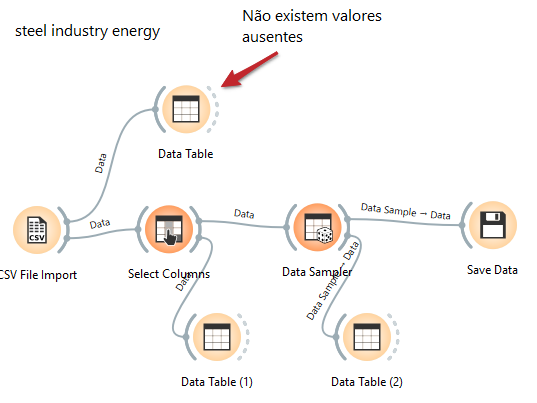

In [ ]:
#criação de um pandas data frame (tabela)
steel = pd.read_csv('/content/steel+industry+energy+consumption.csv')

In [ ]:
steel.rename({'date': 'data',
              'Usage_kWh': 'Consumo_kWh',
              'Lagging_Current_Reactive.Power_kVarh': 'potencia_reativa_1',
              'Leading_Current_Reactive_Power_kVarh': 'potencia_reativa_2',
              'Lagging_Current_Power_Factor': 'fator_potencia_1',
              'Leading_Current_Power_Factor': 'fator_potencia_2',
              'WeekStatus': 'status_semana',
              'Day_of_week': 'dia_semana',
              'Load_Type': 'tipo_carga'}, axis=1, inplace=True)
steel.head()

,data,Consumo_kWh,potencia_reativa_1,potencia_reativa_2,fator_potencia_1,fator_potencia_2,status_semana,dia_semana,tipo_carga
0,29/04/2018 07:15,2.88,3.82,0.0,60.20,100.00,Weekend,Sunday,Light_Load
1,04/10/2018 12:00,60.77,48.02,0.0,78.46,100.00,Weekday,Thursday,Maximum_Load
2,26/01/2018 11:30,120.42,59.65,0.0,89.61,100.00,Weekday,Friday,Maximum_Load
3,02/06/2018 14:30,3.13,0.00,16.6,100.00,18.53,Weekend,Saturday,Light_Load
4,07/12/2018 15:00,58.86,20.99,0.0,94.19,100.00,Weekday,Friday,Medium_Load


In [ ]:
steel.shape

(7008, 9)

In [ ]:
steel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data                7008 non-null   object 
 1   Consumo_kWh         7008 non-null   float64
 2   potencia_reativa_1  7008 non-null   float64
 3   potencia_reativa_2  7008 non-null   float64
 4   fator_potencia_1    7008 non-null   float64
 5   fator_potencia_2    7008 non-null   float64
 6   status_semana       7008 non-null   object 
 7   dia_semana          7008 non-null   object 
 8   tipo_carga          7008 non-null   object 
dtypes: float64(5), object(4)
memory usage: 492.9+ KB


In [ ]:
steel.describe()

,Consumo_kWh,potencia_reativa_1,potencia_reativa_2,fator_potencia_1,fator_potencia_2
count,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,27.790164,13.206839,3.803711,80.672277,84.491448
std,33.717719,16.444246,7.356412,18.869855,30.314798
min,2.450000,0.000000,0.000000,37.870000,12.710000
25%,3.200000,2.380000,0.000000,63.602500,99.710000
50%,4.570000,5.040000,0.000000,87.990000,100.000000
75%,52.107500,22.977500,1.857500,98.842500,100.000000
max,153.140000,87.700000,27.650000,100.000000,100.000000


In [ ]:
# qual é o maior consumo registrado da amostra?
PMAX = steel['Consumo_kWh'].max()
print(f'O maior valor de consumo é {PMAX:.2f} kWh')

O maior valor de consumo é 153.14 kWh


In [ ]:
#qual é o valor do limiar de 75% do consumo máximo (P75)?
P75 = 0.75 * PMAX
print(f'O valor do limiar de 75% do consumo máximo é: {P75:.2f} kWh')

O valor do limiar de 75% do consumo máximo é: 114.85 kWh


In [ ]:
#dataframe com registros acima do valor limite + percentual + quantidade
steel1 = steel[steel['Consumo_kWh'] > P75]
steel1.head()

,data,Consumo_kWh,potencia_reativa_1,potencia_reativa_2,fator_potencia_1,fator_potencia_2,status_semana,dia_semana,tipo_carga
2,26/01/2018 11:30,120.42,59.65,0.0,89.61,100.0,Weekday,Friday,Maximum_Load
62,08/02/2018 14:30,118.22,54.04,0.0,90.95,100.0,Weekday,Thursday,Medium_Load
100,29/01/2018 16:45,129.13,46.58,0.0,94.07,100.0,Weekday,Monday,Medium_Load
108,29/01/2018 14:00,117.07,46.44,0.0,92.95,100.0,Weekday,Monday,Medium_Load
159,22/11/2018 10:15,139.57,58.90,0.0,92.13,100.0,Weekday,Thursday,Maximum_Load


In [ ]:
steel1_alto = pd.DataFrame(steel1)

In [ ]:
# quantidade de registros e percentual
quantidade_registros = len(steel1_alto)
print(f"Quantidade de registros: {quantidade_registros}")

Quantidade de registros: 129


In [ ]:
percentual = len(steel1_alto) / len(steel) * 100
print(f"Percentual de registros: {percentual:.2f}%")

Percentual de registros: 1.84%


In [ ]:
steel1_alto2 = steel1[steel1['Consumo_kWh'] == PMAX]
quantidade_maximum_load = len(steel1_alto2)
print(f"A quantidade de registros que pertencem à categoria Maximum Load é: {quantidade_maximum_load}")

A quantidade de registros que pertencem à categoria Maximum Load é: 1


In [ ]:
limite_fp = 88
steel_critico = steel1_alto[steel1_alto['fator_potencia_1'] < limite_fp]
steel_critico.head()

,data,Consumo_kWh,potencia_reativa_1,potencia_reativa_2,fator_potencia_1,fator_potencia_2,status_semana,dia_semana,tipo_carga
399,11/09/2018 13:45,122.94,69.26,0.0,87.13,100.0,Weekday,Tuesday,Maximum_Load
977,16/03/2018 08:30,118.66,69.26,0.0,86.36,100.0,Weekday,Friday,Light_Load
1634,15/11/2018 08:45,119.12,73.12,0.0,85.22,100.0,Weekday,Thursday,Light_Load
1968,23/10/2018 18:30,125.28,80.46,0.0,84.14,100.0,Weekday,Tuesday,Medium_Load
2433,03/09/2018 16:45,118.04,69.08,0.0,86.31,100.0,Weekday,Monday,Maximum_Load


Explique por que esse segundo conjunto de registros pode merecer maior atenção da equipe de energia.


Requer mais atenção das equipes porque o prejuízo financeiro é maior, pois o consumo está alto, ou seja, a empesa está puxando muita energia de maneira ineficiente (fator de potência mais baixo), a sobrecarga pode causar incêndios, apagão.

# Dataset 3 — Power Consumption of Tetouan City (UCI)

Fonte: https://archive.ics.uci.edu/dataset/849/power+consumption+of+tetouan+city

Situação

Uma equipe responsável pelo planejamento da distribuição de energia em Tétouan deseja identificar qual das três zonas apresenta o maior pico de consumo e observar as condições ambientais registradas nos momentos de maior demanda.

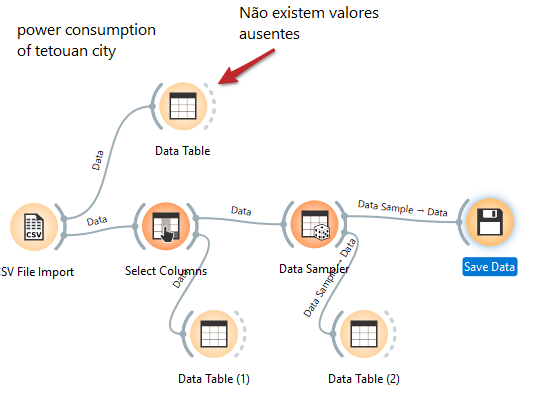

In [ ]:
#criação de um pandas data frame (tabela)
power = pd.read_csv('/content/power+consumption+of+tetouan+city.csv')

In [ ]:
power.head()

,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,22.76,29.73,0.085,32985.1,19396.7,17623.3
1,15.92,54.44,0.085,34737.6,29803.0,14417.3
2,15.08,57.23,0.076,27894.7,20808.5,16458.8
3,12.42,72.30,0.081,42476.9,23634.1,25089.7
4,14.58,80.60,0.080,21341.1,12006.1,11531.6


In [ ]:
power = power.rename(columns={

    "Zone 1 Power Consumption": "Consumo_Zona_1",
    "Zone 2  Power Consumption": "Consumo_Zona_2",
    "Zone 3  Power Consumption": "Consumo_Zona_3"
})

power.head()

,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
0,22.76,29.73,0.085,32985.1,19396.7,17623.3
1,15.92,54.44,0.085,34737.6,29803.0,14417.3
2,15.08,57.23,0.076,27894.7,20808.5,16458.8
3,12.42,72.30,0.081,42476.9,23634.1,25089.7
4,14.58,80.60,0.080,21341.1,12006.1,11531.6


In [ ]:
# qual é o maior consumo da zona 1?
PMAX1 = power['Consumo_Zona_1'].max()
print(f'O maior valor de consumo da zona 1 é {PMAX1:.2f} kWh')

O maior valor de consumo da zona 1 é 51571.50 kWh


In [ ]:
# qual é o maior consumo da zona 2?
PMAX2 = power['Consumo_Zona_2'].max()
print(f'O maior valor de consumo da zona 2 é {PMAX2:.2f} kWh')

O maior valor de consumo da zona 2 é 36437.20 kWh


In [ ]:
# qual é o maior consumo da zona 3?
PMAX3 = power['Consumo_Zona_3'].max()
print(f'O maior valor de consumo da zona 3 é {PMAX3:.2f} kWh')

O maior valor de consumo da zona 3 é 47441.70 kWh


In [ ]:
# a zona 1 é a com maior pico de consumo na amostra
P7 = 0.7 * PMAX1
print(f'O valor do limiar de 70% do consumo máximo da zona 1 é: {P7:.2f} kWh')

O valor do limiar de 70% do consumo máximo da zona 1 é: 36100.05 kWh


In [ ]:
#dataframe com registros acima do limiar de 70%
power1 = power[power['Consumo_Zona_1'] > P7]
power1.head()

,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
3,12.42,72.30,0.081,42476.9,23634.1,25089.7
8,14.66,65.92,0.075,37286.7,30716.2,15834.8
12,21.03,86.50,0.068,40993.9,25383.4,24960.0
14,27.06,47.58,4.905,37475.2,24276.2,25140.6
19,19.20,65.81,4.924,40676.0,24754.7,25095.9


In [ ]:
power1_alto = pd.DataFrame(power1)
quantidade_registros = len(power1_alto)
print(f"Quantidade de registros: {quantidade_registros}")

Quantidade de registros: 2388


In [ ]:
percentual = len(power1_alto) / len(power) * 100
print(f"Percentual de registros: {percentual:.2f}%")

Percentual de registros: 30.37%


In [ ]:
media_temperatura = power['Temperature'].mean()
print(f"a média da temperatura 1 é: {media_temperatura:.2f}")

a média da temperatura 1 é: 18.79


In [ ]:
power2= power1[power1['Temperature'] > media_temperatura]
power2.head()

,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
12,21.03,86.50,0.068,40993.9,25383.4,24960.0
14,27.06,47.58,4.905,37475.2,24276.2,25140.6
19,19.20,65.81,4.924,40676.0,24754.7,25095.9
21,27.11,43.35,4.906,40256.1,27416.3,25453.5
25,26.92,70.20,4.909,36511.9,25906.3,25654.9


Compare os dois conjuntos e explique o que ocorreu com a quantidade de registros após a inclusão da condição ambiental.

A quantidade de registros sofreu uma queda drástica, em razão dos picos térmicos, quando as temperaturas estão acima da média, significa que está mais quente, provocando um uso maior de ar-condicionado e sistemas de refrigeração, o que indica o maior consumo ao mesmo tempo das temperaturas mais altas.

# Dataset 4 — Solar Power Generation Data (Kaggle)

Fonte: https://www.kaggle.com/datasets/anikannal/solar-power-generation-data?resource=download

Situação

Uma equipe de operação de uma usina fotovoltaica deseja localizar períodos de alta geração e identificar quais inversores aparecem com maior frequência nesses momentos. Nesta atividade, o foco inicial será o arquivo de geração da planta, sem realizar junção com o arquivo de sensores.

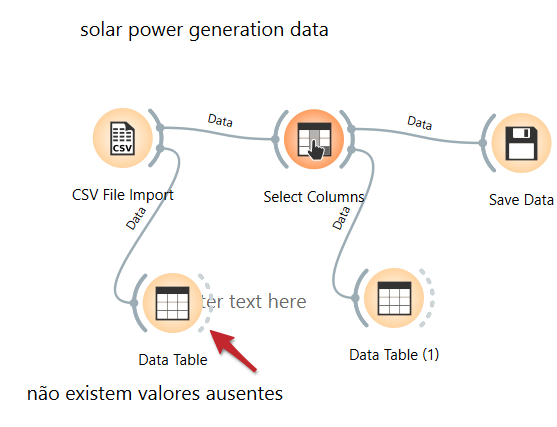

In [ ]:
#criação de um pandas data frame (tabela)
solar = pd.read_csv('/content/orange4_solar_data.csv.csv')

In [ ]:
solar.head()

,DATE_TIME,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-06-10 19:00:00,uHbuxQJl8lW7ozc,0.00,0.000,6645.000,7240510.0
1,2020-05-28 00:15:00,rGa61gmuvPhdLxV,0.00,0.000,0.000,7206550.0
2,2020-05-17 15:15:00,sjndEbLyjtCKgGv,7333.88,718.062,6442.000,7036060.0
3,2020-06-01 04:15:00,ih0vzX44oOqAx2f,0.00,0.000,0.000,6308230.0
4,2020-05-17 09:00:00,z9Y9gH1T5YWrNuG,7665.50,750.438,961.375,7021700.0


In [ ]:
solar.rename({'DATE_TIME': 'data_hora',
              'SOURCE_KEY': 'chave',
              'DC_POWER': 'corrente_continua',
              'AC_POWER': 'corrente_alternada',
              'DAILY_YIELD': 'rendimento_dia',
              'TOTAL_YIELD': 'rendimento_total'}, axis=1, inplace=True)
solar.head()

,data_hora,chave,corrente_continua,corrente_alternada,rendimento_dia,rendimento_total
0,2020-06-10 19:00:00,uHbuxQJl8lW7ozc,0.00,0.000,6645.000,7240510.0
1,2020-05-28 00:15:00,rGa61gmuvPhdLxV,0.00,0.000,0.000,7206550.0
2,2020-05-17 15:15:00,sjndEbLyjtCKgGv,7333.88,718.062,6442.000,7036060.0
3,2020-06-01 04:15:00,ih0vzX44oOqAx2f,0.00,0.000,0.000,6308230.0
4,2020-05-17 09:00:00,z9Y9gH1T5YWrNuG,7665.50,750.438,961.375,7021700.0


In [ ]:
solar.shape

(13756, 6)

In [ ]:
solar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13756 entries, 0 to 13755
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_hora           13756 non-null  object 
 1   chave               13756 non-null  object 
 2   corrente_continua   13756 non-null  float64
 3   corrente_alternada  13756 non-null  float64
 4   rendimento_dia      13756 non-null  float64
 5   rendimento_total    13756 non-null  float64
dtypes: float64(4), object(2)
memory usage: 644.9+ KB


In [ ]:
solar.describe()

,corrente_continua,corrente_alternada,rendimento_dia,rendimento_total
count,13756.000000,13756.000000,13756.000000,1.375600e+04
mean,3135.848662,306.695495,3319.235216,6.978829e+06
std,4023.069619,393.124284,3142.249927,4.162164e+05
min,0.000000,0.000000,0.000000,6.183640e+06
25%,0.000000,0.000000,0.000000,6.509780e+06
50%,370.071500,35.771400,2730.425000,7.146220e+06
75%,6350.562500,622.065500,6293.782500,7.268000e+06
max,14416.100000,1405.590000,9163.000000,7.846820e+06


In [ ]:
#maior potência CA registrada
PMAX = solar['corrente_alternada'].max()
print(f'A maior potência de corrente alternada é {PMAX:.2f}kW')

A maior potência de corrente alternada é 1405.59kW


In [ ]:
#limiar correspondente a 70% da potência CA máxima
P70 = 0.70 * PMAX
print(f'O valor do limiar de 70% da potência CA máxima é: {P70:.2f} kW')

O valor do limiar de 70% da potência CA máxima é: 983.91 kW


In [ ]:
#DataFrame contendo somente registros acima desse limite e calcule sua quantidade e percentual
solar1 = solar[solar['corrente_alternada'] > P70]
solar1.head()

,data_hora,chave,corrente_continua,corrente_alternada,rendimento_dia,rendimento_total
11,2020-05-26 12:15:00,bvBOhCH3iADSZry,11830.1,1153.83,4028.14,6396360.0
46,2020-06-15 14:30:00,wCURE6d3bPkepu2,10571.3,1032.07,5366.57,7015060.0
48,2020-05-25 10:15:00,z9Y9gH1T5YWrNuG,11050.1,1079.86,2174.29,7082810.0
72,2020-06-13 11:30:00,7JYdWkrLSPkdwr4,11094.5,1082.44,3570.25,7815990.0
76,2020-06-07 13:00:00,VHMLBKoKgIrUVDU,12663.4,1234.69,4976.71,7382970.0


In [ ]:
solar1_alto = pd.DataFrame(solar1)
quantidade_registros = len(solar1_alto)
print(f"Quantidade de registros: {quantidade_registros}")

Quantidade de registros: 1185


In [ ]:
percentual = len(solar1_alto) / len(solar) * 100
print(f"Percentual de registros: {percentual:.2f}%")

Percentual de registros: 8.61%


In [ ]:
#value_counts() em SOURCE_KEY dentro do DataFrame de alta geração
print(solar1_alto['chave'].value_counts())

chave
adLQvlD726eNBSB    68
McdE0feGgRqW7Ca    65
ZnxXDlPa8U1GXgE    63
pkci93gMrogZuBj    62
ZoEaEvLYb1n2sOq    61
1IF53ai7Xc0U56Y    59
YxYtjZvoooNbGkE    58
sjndEbLyjtCKgGv    57
z9Y9gH1T5YWrNuG    56
uHbuxQJl8lW7ozc    55
zVJPv84UY57bAof    54
zBIq5rxdHJRwDNY    53
ih0vzX44oOqAx2f    53
WRmjgnKYAwPKWDb    52
3PZuoBAID5Wc2HD    51
iCRJl6heRkivqQ3    51
VHMLBKoKgIrUVDU    51
wCURE6d3bPkepu2    49
rGa61gmuvPhdLxV    43
7JYdWkrLSPkdwr4    43
1BY6WEcLGh8j5v7    42
bvBOhCH3iADSZry    39
Name: count, dtype: int64


Identifique qual inversor aparece com maior frequência nos registros de alta geração e descreva o que esse resultado permite observar, sem concluir desempenho ou falha apenas com esse recorte.

O inversor que aparcee com mais frequência é a chave adLQvlD726eNBSB, aparecendo 68 vezes.

# Dataset 5 — Wind & Solar Energy Production (Kaggle)

Fonte: https://www.kaggle.com/datasets/ahmeduzaki/wind-and-solar-energy-production-dataset

Situação

Um operador de um portfólio de fontes renováveis deseja comparar a ocorrência de períodos de alta produção solar e alta produção eólica. Como as duas fontes possuem escalas próprias, cada uma deverá ser comparada com o seu próprio valor máximo.

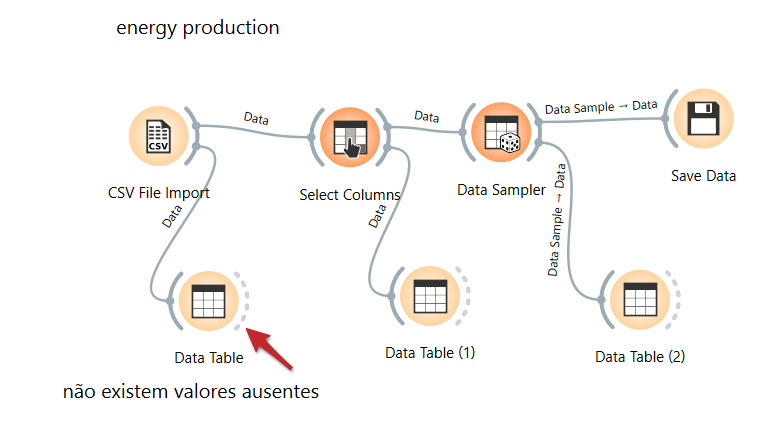

In [ ]:
#criação de um pandas data frame (tabela)
wind = pd.read_csv('/content/orange5.csv.csv')

In [ ]:
wind.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,2022-12-18 00:00:00,21,22,Wind,352,Sunday,December,Winter,11400
1,2024-01-29 00:00:00,14,15,Wind,29,Monday,January,Winter,7917
2,2024-08-01 00:00:00,15,16,Solar,214,Thursday,August,Summer,8835
3,2020-11-10 00:00:00,1,2,Wind,315,Tuesday,November,Fall,989
4,2022-12-19 00:00:00,1,2,Wind,353,Monday,December,Winter,12526


In [ ]:
wind_solar_bruto = wind[wind['Source'] == 'Solar']
wind_eolica_bruto = wind[wind['Source'] == 'Wind']
wind_solar_bruto.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
2,2024-08-01 00:00:00,15,16,Solar,214,Thursday,August,Summer,8835
5,2024-10-18 00:00:00,13,14,Solar,292,Friday,October,Fall,4855
6,2020-04-10 00:00:00,17,18,Solar,101,Friday,April,Spring,3692
13,2021-06-02 00:00:00,15,16,Solar,153,Wednesday,June,Summer,5561
16,2021-05-02 00:00:00,13,14,Solar,122,Sunday,May,Spring,4993


In [ ]:
#Renomeie as variáveis principais para Geracao_Solar e Geracao_Eolica
wind.rename({'Date': 'data',
              'Start_Hour': 'inicio',
              'End_Hour': 'termino',
              'Source': 'fonte',
              'Day_of_Year': 'dia_ano',
              'Day_Name': 'dia_semana',
              'Month_Name': 'mes',
              'Season': 'estacao',
              'Production': 'producao'}, axis=1, inplace=True)
wind.head()

,data,inicio,termino,fonte,dia_ano,dia_semana,mes,estacao,producao
0,2022-12-18 00:00:00,21,22,Wind,352,Sunday,December,Winter,11400
1,2024-01-29 00:00:00,14,15,Wind,29,Monday,January,Winter,7917
2,2024-08-01 00:00:00,15,16,Solar,214,Thursday,August,Summer,8835
3,2020-11-10 00:00:00,1,2,Wind,315,Tuesday,November,Fall,989
4,2022-12-19 00:00:00,1,2,Wind,353,Monday,December,Winter,12526


In [ ]:
#Determine o valor máximo registrado para cada fonte
print(wind.groupby('fonte')['producao'].max())


fonte
Solar    16316
Wind     22929
Name: producao, dtype: int64


In [ ]:
#Calcule separadamente 70% do máximo solar e 70% do máximo eólico
max_solar = wind[wind['fonte'] == 'Solar']['producao'].max()
P70_solar = max_solar * 0.7
print(f"70% do máximo solar é: {P70_solar:.2f}")

70% do máximo solar é: 11421.20


In [ ]:
max_eolico = wind[wind['fonte'] == 'Wind']['producao'].max()
P70_eolico = max_eolico * 0.7
print(f"70% do máximo eólico é: {P70_eolico:.2f}")

70% do máximo eólico é: 16050.30


In [ ]:
#Crie um DataFrame para registros de alta geração solar e outro para registros de alta geração eólica
wind_alta_solar = wind[(wind['fonte'] == 'Solar') & (wind['producao'] > P70)]
wind_alta_solar.head()

,data,inicio,termino,fonte,dia_ano,dia_semana,mes,estacao,producao
2,2024-08-01 00:00:00,15,16,Solar,214,Thursday,August,Summer,8835
5,2024-10-18 00:00:00,13,14,Solar,292,Friday,October,Fall,4855
6,2020-04-10 00:00:00,17,18,Solar,101,Friday,April,Spring,3692
13,2021-06-02 00:00:00,15,16,Solar,153,Wednesday,June,Summer,5561
16,2021-05-02 00:00:00,13,14,Solar,122,Sunday,May,Spring,4993


In [ ]:
wind_alta_eolico = wind[(wind['fonte'] == 'Wind') & (wind['producao'] > P70)]
wind_alta_eolico.head()

,data,inicio,termino,fonte,dia_ano,dia_semana,mes,estacao,producao
0,2022-12-18 00:00:00,21,22,Wind,352,Sunday,December,Winter,11400
1,2024-01-29 00:00:00,14,15,Wind,29,Monday,January,Winter,7917
3,2020-11-10 00:00:00,1,2,Wind,315,Tuesday,November,Fall,989
4,2022-12-19 00:00:00,1,2,Wind,353,Monday,December,Winter,12526
7,2023-01-25 00:00:00,0,1,Wind,25,Wednesday,January,Winter,2156


In [ ]:
wind_alta_eolico.shape

(8247, 9)

In [ ]:
total_solar_bruto = len(wind[wind['fonte'] == 'Solar'])
total_eolica_bruto = len(wind[wind['fonte'] == 'Wind'])

qtd_alta_solar = len(wind_alta_solar)
qtd_alta_eolica = len(wind_alta_eolico)

pct_alta_solar = (qtd_alta_solar / total_solar_bruto) * 100
pct_alta_eolica = (qtd_alta_eolica / total_eolica_bruto) * 100

print(f"Solar -> registros altos: {qtd_alta_solar}, ({pct_alta_solar:.2f}%)")
print(f"Eólico -> registros altos: {qtd_alta_eolica}, ({pct_alta_eolica:.2f}%)")


Solar -> registros altos: 1842, (99.78%)
Eólico -> registros altos: 8247, (96.72%)


In [ ]:
#Compare qual fonte aparece com maior frequência acima de 70% do seu próprio máximo

# A fonte solar tem maior frequência, ndicando que opera mais próximo da sua capacidade máxima nas condições climáticas da amostra

Explique por que não seria adequado utilizar diretamente o mesmo valor numérico de potência como limite para as duas fontes sem antes observar a escala de cada variável.

A duas fontes tem jeitos diferentes de produzirem energia, a solar é mais estável, sendo maior de manhã e menor no final do dia, já a eólica depende toda hora dos ventos

# Dataset 6 — Individual Household Electric Power Consumption (UCI)

Fonte: https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

Situação

Uma residência possui monitoramento elétrico detalhado e deseja identificar episódios de demanda elevada que também apresentem corrente acima do comportamento médio. O dataset é o mesmo utilizado como referência em aula, mas o critério de análise será diferente.

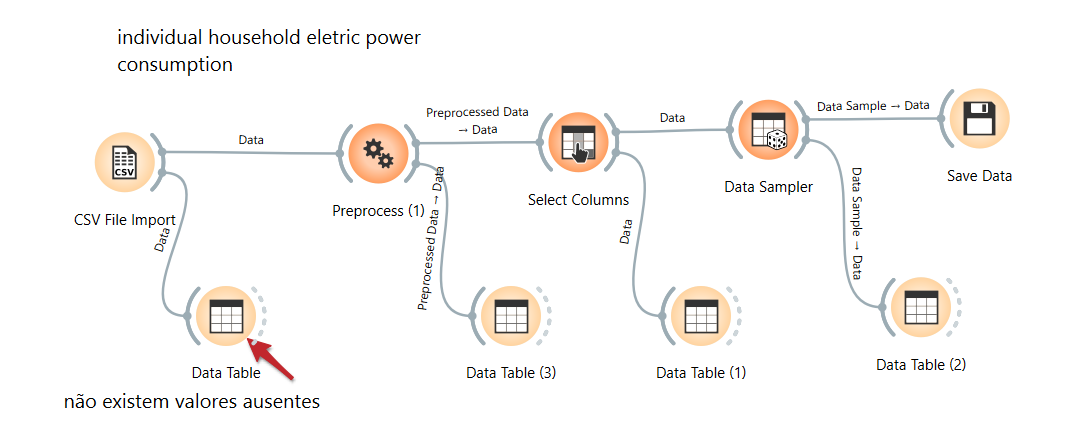

In [ ]:
#criação de um pandas data frame (tabela)
household = pd.read_csv('/content/orange6_household_Data.csv')

In [ ]:
household.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0.256,0.106,242.00,1.2,0.0,0.0,1.0
1,0.466,0.352,237.22,2.4,0.0,2.0,0.0
2,0.758,0.194,238.66,3.2,0.0,1.0,0.0
3,1.290,0.046,240.64,5.4,1.0,0.0,18.0
4,0.428,0.202,242.23,1.8,0.0,2.0,1.0


In [ ]:
#organize os atributos utilizando nomes mais simples
household.rename({'Global_active_power': 'pot_ativa',
              'Global_reactive_power': 'pot_reativa',
              'Voltage': 'voltagem',
              'Global_intensity': 'corrente',
              'Sub_metering_1': 'medicao_1',
              'Sub_metering_2': 'medicao_2',
              'Sub_metering_3': 'medicao_3'}, axis=1, inplace=True)
household.head()

,pot_ativa,pot_reativa,voltagem,corrente,medicao_1,medicao_2,medicao_3
0,0.256,0.106,242.00,1.2,0.0,0.0,1.0
1,0.466,0.352,237.22,2.4,0.0,2.0,0.0
2,0.758,0.194,238.66,3.2,0.0,1.0,0.0
3,1.290,0.046,240.64,5.4,1.0,0.0,18.0
4,0.428,0.202,242.23,1.8,0.0,2.0,1.0


In [ ]:
#Determine o valor máximo de potência ativa
PMAX = household['pot_ativa'].max()
print(f'O maior valor da potência ativa é {PMAX:.2f} kW')

O maior valor da potência ativa é 10.65 kW


In [ ]:
#Calcule 75% do valor máximo e crie um DataFrame contendo registros acima desse limite
P75 = 0.75 * PMAX
print(f'O valor do limiar de 75% da potência máxima é: {P75:.2f} kW')

O valor do limiar de 75% da potência máxima é: 7.99 kW


In [ ]:
household1 = household[household['pot_ativa'] > P75]
household1.head()

,pot_ativa,pot_reativa,voltagem,corrente,medicao_1,medicao_2,medicao_3
24635,8.110,0.196,236.87,34.2,37.0,74.0,17.0
42771,8.026,0.058,234.91,34.0,37.0,73.0,17.0
45962,8.218,0.336,236.05,34.8,37.0,73.0,17.0
46828,9.708,0.372,231.37,42.0,37.0,69.0,17.0
55667,8.168,0.540,228.91,35.6,35.0,35.0,17.0


In [ ]:
household1.shape

(33, 7)

In [ ]:
#Calcule a quantidade e o percentual de registros selecionados.
household1_alto = pd.DataFrame(household1)
quantidade_registros = len(household1_alto)
print(f"Quantidade de registros: {quantidade_registros}")

Quantidade de registros: 33


In [ ]:
percentual = len(household1_alto) / len(household) * 100
print(f"Percentual de registros: {percentual:.2f}%")

Percentual de registros: 0.02%


In [ ]:
#Calcule a corrente média da amostra.
media_corrente = household1['corrente'].mean()
print(f"a média da corrente é: {media_corrente:.2f} A")

a média da corrente é: 36.67 A


In [ ]:
#Crie um segundo DataFrame contendo simultaneamente potência ativa acima de 75% do máximo e corrente acima da média.
household2= household1[household1['corrente'] > media_corrente]
household2.head()

,pot_ativa,pot_reativa,voltagem,corrente,medicao_1,medicao_2,medicao_3
46828,9.708,0.372,231.37,42.0,37.0,69.0,17.0
64690,8.716,0.534,227.63,38.2,35.0,35.0,16.0
108609,9.108,0.000,232.08,39.2,37.0,71.0,17.0
109204,10.650,0.500,229.97,46.4,36.0,70.0,17.0
111900,8.556,0.060,234.09,36.8,36.0,54.0,17.0
